In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df_diabetes = pd.read_csv('diabetes.csv')
df_diabetes.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [8]:
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [24]:
profile = pd.DataFrame({
    "dtype": df_diabetes.dtypes.astype(str),
    "missing": df_diabetes.isna().sum(),
    "missing_pct": (df_diabetes.isna().mean() * 100).round(2),
    "unique": df_diabetes.nunique()
})
profile.sort_values(["missing", "unique"], ascending=[False, False]).head(10)

,dtype,missing,missing_pct,unique
BMI,float64,0,0.0,84
MentHlth,float64,0,0.0,31
PhysHlth,float64,0,0.0,31
Age,float64,0,0.0,13
Income,float64,0,0.0,8
Education,float64,0,0.0,6
GenHlth,float64,0,0.0,5
Diabetes_012,float64,0,0.0,3
HighBP,float64,0,0.0,2
HighChol,float64,0,0.0,2


In [29]:
target_counts = df_diabetes["Diabetes_012"].value_counts()
target_pct = (target_counts / len(df_diabetes) * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct
})
target_summary

,count,percentage
Diabetes_012,,
0.0,213703,84.24
2.0,35346,13.93
1.0,4631,1.83


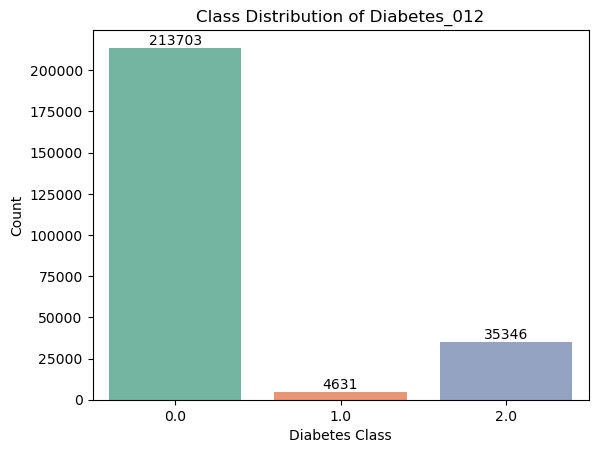

In [30]:
ax = sns.countplot(
    data=df_diabetes,
    x="Diabetes_012",
    hue="Diabetes_012",
    palette="Set2",
    legend=False
)
ax.set_title("Class Distribution of Diabetes_012")
ax.set_xlabel("Diabetes Class")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container)
plt.show()